Diabetes Risk Clusters
Scenario

We have patients with:

blood glucose
BMI

We want to group them into:

low risk
medium risk
high risk

1. Create Toy Patient Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Low-risk patients
low_risk = np.random.normal(loc=[90, 22], scale=[8, 2], size=(50, 2))

# Medium-risk patients
medium_risk = np.random.normal(loc=[130, 28], scale=[10, 3], size=(50, 2))

# High-risk patients
high_risk = np.random.normal(loc=[180, 35], scale=[12, 4], size=(50, 2))

# Combine data
data = np.vstack([low_risk, medium_risk, high_risk])

df = pd.DataFrame(data, columns=["Glucose", "BMI"])

What this does
Creates 150 fake patients
Simulates 3 health groups
Pattern
np.random.normal(mean, std, size)
np.vstack()

2. Run Clustering

In [2]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(df)

What this does
Groups similar patients automatically
Pattern
model = KMeans(n_clusters=3)
labels = model.fit_predict(data)

3. Measure Confidence (Distance to Cluster Center)

In [3]:
# Distance of each patient to all cluster centers
distances = kmeans.transform(df[["Glucose", "BMI"]])

# Distance to assigned center
assigned_dist = np.min(distances, axis=1)

# Convert distance to simple confidence score
df["Confidence"] = 1 / (1 + assigned_dist)

What this does
Patients near cluster center = higher confidence
Borderline patients = lower confidence
Pattern
distances = model.transform(data)
confidence = 1 / (1 + distance)

4. Set Clinical Action Thresholds

In [4]:
def action_rule(conf):
    if conf > 0.7:
        return "Auto-care pathway"
    elif conf > 0.5:
        return "Doctor review"
    else:
        return "Standard care"

df["Action"] = df["Confidence"].apply(action_rule)

Example meaning
High confidence → trust cluster recommendation
Medium → doctor checks
Low → don’t rely on cluster

5. Visualize Clusters

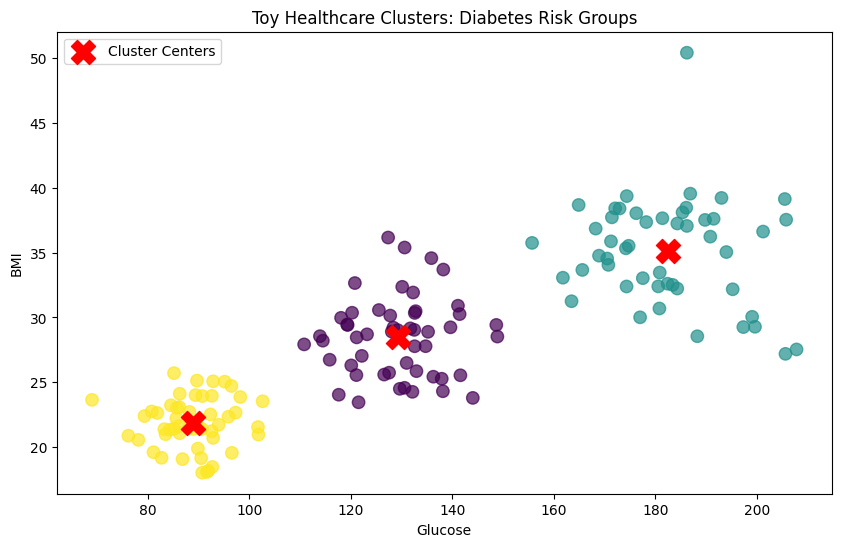

In [5]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["Glucose"],
    df["BMI"],
    c=df["Cluster"],
    cmap="viridis",
    s=80,
    alpha=0.7
)

# Mark cluster centers
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="red",
    s=300,
    marker="X",
    label="Cluster Centers"
)

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Toy Healthcare Clusters: Diabetes Risk Groups")
plt.legend()
plt.show()

What You’ll See
3 visible patient groups
Red X = center of each cluster
Interpretation
Patients near center:
similar to others in group
high confidence
Patients at edges:
mixed patterns
need review

6. Show Uncertain Patients

In [6]:
uncertain = df[df["Confidence"] < 0.5]
print(uncertain.head())

      Glucose        BMI  Cluster  Confidence         Action
0   93.973713  21.723471        2    0.164993  Standard care
1   95.181508  25.046060        2    0.124500  Standard care
3  102.633703  23.534869        2    0.067470  Standard care
4   86.244205  23.085120        2    0.253827  Standard care
5   86.292658  21.068540        2    0.267550  Standard care


Why this matters

These are patients:

between groups
not fitting cleanly
Clinical use

Doctor reviews:

labs
symptoms
follow-up history

Real Healthcare Meaning

This mirrors real workflows:

cluster finds hidden patterns
confidence decides trust level
clinician reviews unclear cases
Example:

A patient:

glucose = 175
BMI = 34
high confidence high-risk cluster
→ early endocrinology referral

Another:

glucose = 140
BMI = 29
medium confidence
→ manual review first